In [14]:
import pandas as pd
import numpy as np
import os, sys, importlib, time
from tqdm import tqdm
tqdm.pandas()
sys.path.append(os.path.abspath(".."))
import matplotlib.pyplot as plt
%matplotlib inline

# models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay

# myutils :
from utils import axe_classification
importlib.reload(axe_classification)

from utils.axe_classification import to_df_long, split_axe, emb_text
from utils.axe_classification import mlp_multilabels, predict_by_mlp, evaluate_model

In [ ]:
df=pd.read_csv("../sandbox\data/20251201-ProductionScientifiqueIRG-__-202512_2734art.csv")

df_before_2024=df[df["submittedDate_s"]<="2024-12-31 23:59:59"]#before2024
print(df_before_2024.axe.value_counts(dropna=False)/len(df_before_2024))
# df_before_2024.to_csv("../sandbox\data/20251201-ProductionScientifiqueIRG-__-202412_2486art.csv")

df_before_2024_hasaxe=df_before_2024[df_before_2024['axe'].notna()]#has axe
print(len(df), len(df_before_2024), len(df_before_2024_hasaxe))
print(df_before_2024_hasaxe.axe.value_counts(dropna=False))


2734 2486 2021
axe
3       0.422365
1       0.262671
NaN     0.187047
2       0.100965
4       0.018504
2; 3    0.003218
1; 3    0.002816
1; 2    0.001609
3; 1    0.000402
3; 4    0.000402
Name: count, dtype: float64
axe
3       1050
1        653
2        251
4         46
2; 3       8
1; 3       7
1; 2       4
3; 1       1
3; 4       1
Name: count, dtype: int64


## split axes

## emb

In [2]:
pq_path="../external_data\embeddings_all/df_all_3emb.parquet"
embeddings=pd.read_parquet(pq_path)
# display(embeddings.head())
embeddings.axe.value_counts(dropna=False)
display(embeddings.head())

,halId_s,uri_s,docType_s,title_s,subTitle_s,authFullName_s,authIdHal_s,labStructName_s,author_primarystructure_s,collName_s,...,urlFulltextEsr_s,fnege_year,axes_vec,axe1,axe2,axe3,axe4,emb_title_s,emb_keyword_s,emb_abstract_s
14,hal-05354091,https://hal.science/hal-05354091v1,COMM,Les jeux vidéo FLOSS dans l’enseignement supér...,None,Philippe Lépinard,philippe-lepinard,Institut de Recherche en Gestion,1004418_Institut de Recherche en Gestion,Sciences de l'Homme et de la Société; Biblioth...,...,NaN,2022,"[0, 0, 1, 0]",0,0,1,0,"[-0.07416533, -0.02507004, -0.056212127, -0.00...","[-0.038245093, -0.003676773, -0.055256307, -0....","[-0.0627323, -0.012661392, -0.04260565, -0.003..."
20,hal-05321456,https://hal.u-pec.fr/hal-05321456v1,COUV,Unlocking Organizational Identity,A Consultant’s Playbook for Inclusion Advocacy,Éric Gautier Laurent; Catherine Voynnet-Fourboul,eric-gautier; catherine-voynnet-fourboul,Institut de Recherche en Gestion; Laboratoire ...,1004418_Institut de Recherche en Gestion;10964...,Sciences de l'Homme et de la Société; Universi...,...,NaN,2022,"[0, 0, 1, 0]",0,0,1,0,"[-0.022757635, -0.0064444183, -0.042470817, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
33,hal-05302743,https://hal.science/hal-05302743v1,ART,Les Remote Carriers dans le combat collaborati...,None,Juliette Frédy; Cécile Godé; Philippe Lépinard,cecile-gode; philippe-lepinard,Centre d'Études et de Recherche en Gestion d'A...,420786_Université Paris-Est Créteil Val-de-Mar...,Sciences de l'Homme et de la Société; Universi...,...,NaN,2022,"[0, 0, 1, 0]",0,0,1,0,"[-0.03761582, -0.006678919, -0.009912152, 0.01...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.074023664, 0.021094285, -0.00791859, 0.025..."
40,hal-05295448,https://hal.science/hal-05295448v1,ART,Frugalité technologique et ludopédagogie en ma...,None,Philippe Lépinard; Prabpreet Singh,philippe-lepinard,Institut de Recherche en Gestion,1004418_Institut de Recherche en Gestion;17672...,Sciences de l'Homme et de la Société; Biblioth...,...,NaN,2022,"[0, 0, 1, 0]",0,0,1,0,"[-0.081040576, 0.0018408684, -0.008541116, 0.0...","[-0.062362764, -0.028598065, -0.051758498, -0....","[-0.07686497, -0.0064801904, -0.03617584, -0.0..."
42,hal-05288245,https://hal.science/hal-05288245v1,COUV,Perspectives pédagogiques ! Frugalité technolo...,None,Philippe Lépinard,philippe-lepinard,Institut de Recherche en Gestion,1004418_Institut de Recherche en Gestion,Sciences de l'Homme et de la Société; Biblioth...,...,NaN,2022,"[0, 0, 1, 0]",0,0,1,0,"[-0.09261081, -0.01070483, -0.017841782, 0.000...","[-0.054620333, -0.028326109, -0.0541471, 0.001...","[-0.07495657, 0.0016563429, -0.018859863, 0.01..."


In [ ]:
embeddings_2024=embeddings[embeddings["submittedDate_s"]<="2024-12-31 23:59:59"]
embeddings_after_2024=embeddings[~embeddings['halId_s'].isin(embeddings_2024['halId_s'])]
embeddings_noaxe=embeddings[embeddings['axe'].isna()]

print(len(embeddings),len(embeddings_2024), len(embeddings_after_2024), len(embeddings_noaxe))
# display(embeddings_noaxe.head())


##save:
outpath_2024="../external_data/embeddings_all/df_before2024_3emb.parquet"
outpath_after_2024="../external_data/embeddings_all/df_after2024_3emb.parquet"
outpath_noaxe="../external_data/embeddings_all/df_noaxe_3emb.parquet"

os.makedirs(os.path.dirname(outpath_2024), exist_ok=True)
embeddings_2024.to_parquet(outpath_2024)
embeddings_after_2024.to_parquet(outpath_after_2024)
embeddings_noaxe.to_parquet(outpath_noaxe)

2734 2486 248 617


,halId_s,uri_s,docType_s,title_s,subTitle_s,authFullName_s,authIdHal_s,labStructName_s,author_primarystructure_s,collName_s,...,urlFulltextEsr_s,fnege_year,axes_vec,axe1,axe2,axe3,axe4,emb_title_s,emb_keyword_s,emb_abstract_s
0,hal-05388365,https://hal.science/hal-05388365v1,ART,Entrepreneuriat de nécessité (versus opportuni...,None,Nongainéba Benjamin Zoumba; Blaise Wendwaoga S...,None,Institut de Recherche en Gestion,57129_Institut de Recherche en Gestion;no prim...,Sciences de l'Homme et de la Société; Universi...,...,NaN,2022,"[0, 0, 0, 0]",0,0,0,0,"[-0.04155007, -0.023307052, 0.0016010036, -0.0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.018936373, -0.021172136, -0.0118464315, -0..."
1,hal-05388364,https://hal.science/hal-05388364v1,COMM,Responsible entrepreneurship: From motivations...,None,Nongainéba Benjamin Zoumba; Sandwidi Blaise We...,None,Institut de Recherche en Gestion,57129_Institut de Recherche en Gestion;57129_I...,None,...,NaN,2019,"[0, 0, 0, 0]",0,0,0,0,"[-0.016558325, -0.03287933, -0.008555193, -0.0...","[0.012655695, -0.021638852, -0.016811978, -0.0...","[-0.026050236, -0.036349155, -0.027868139, -0...."
2,hal-05385243,https://hal.science/hal-05385243v1,COMM,Agencer des safe spaces en marketing des servi...,None,Sacha Bensahel-Mercier; Amina Béji-Bécheur; So...,sacha-bensahel-mercier; amina-beji-becheur; so...,Institut de Recherche en Gestion; Institut de ...,1004418_Institut de Recherche en Gestion;57129...,Sciences de l'Homme et de la Société; Universi...,...,NaN,2022,"[0, 0, 0, 0]",0,0,0,0,"[-0.054544363, 0.0029261268, -0.037374336, 0.0...","[-0.04776228, 0.03034196, -0.00890015, 0.00737...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,hal-05384860,https://hal.science/hal-05384860v1,ART,The Financial Crisis of 1825: The Making of a ...,None,Nesrine Bentemessek Kahia,nesrine-bentemessek-kahia,Institut de Recherche en Gestion; Institut de ...,57129_Institut de Recherche en Gestion,Institut de Recherche en Gestion; Université P...,...,NaN,2022,"[0, 0, 0, 0]",0,0,0,0,"[0.015976597, -0.0061338134, -0.019945806, 0.0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,hal-05383407,https://hal.science/hal-05383407v1,COMM,Repenser la responsabilité sociétale des marqu...,None,Philippe Jourdan; Jean-Claude Pacitto; Valérie...,philippe-jourdan,Institut de Recherche en Gestion; IUT Creteil-...,784_Centre d'études et de recherches appliquée...,Sciences de l'Homme et de la Société; Universi...,...,NaN,2022,"[0, 0, 0, 0]",0,0,0,0,"[-0.049852498, 0.017654063, -0.017948851, -0.0...","[-0.06879571, 0.016883908, -0.008853269, -0.01...","[-0.0483168, 0.025082415, -0.033493362, -0.007..."


## filtrer & to df long:

In [15]:
pq_path="../external_data\embeddings_all\df_before2024_3emb.parquet"
df=pd.read_parquet(pq_path)
df_hasaxe=df[df['axe'].notna()]
print(len(df), len(df_hasaxe))

# tolong
df_long=df_long=to_df_long(df_hasaxe, cols=['emb_title_s','emb_keyword_s','emb_abstract_s'])
print(len(df_long))
display(df_long.head())


2486 2021
4533


,text_emb,halId_s,source,axe1,axe2,axe3,axe4,source_id,source_vec
0,"[-0.067080185, -0.0033619883, -0.057862666, 0....",hal-04836262,title,1.0,0.0,0.0,0.0,0,"[1.0, 0.0, 0.0]"
1,"[-0.05938513, 0.015668642, -0.0027596208, -0.0...",hal-04836262,keyword,1.0,0.0,0.0,0.0,1,"[0.0, 1.0, 0.0]"
2,"[-0.06698241, 0.012503117, -0.031837963, 0.012...",hal-04836262,abstract,1.0,0.0,0.0,0.0,2,"[0.0, 0.0, 1.0]"
3,"[-0.05644952, -0.015046884, -0.0052401857, -0....",hal-04834794,title,0.0,0.0,1.0,0.0,0,"[1.0, 0.0, 0.0]"
4,"[-0.0025393004, -0.017068807, -0.007008952, 0....",hal-04834794,keyword,0.0,0.0,1.0,0.0,1,"[0.0, 1.0, 0.0]"


## train clf

### 3embs


In [16]:
import pandas as pd
import torch 
import numpy as np
from sklearn.model_selection import train_test_split
importlib.reload(axe_classification)
from utils.axe_classification import mlp_multilabels


# ----------------------------------import data-------------------------------
df_long_totrain=df_long
X = np.concatenate([df_long_totrain["text_emb"].tolist(), df_long_totrain["source_vec"].tolist()], axis=1)
y = df_long_totrain[['axe1','axe2','axe3','axe4']].values.astype(np.float32)
#text+source=1024+3=1027

#-------------------------------- split data---------------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"[INFO]train/test : {X_train.shape}, {X_val.shape}")


[INFO]train/test : (3626, 1027), (907, 1027)


In [18]:
importlib.reload(axe_classification)
from utils.axe_classification import train_multilabel_mlp_3class
model_mlp, best_t_overall=train_multilabel_mlp_3class (X_train,X_val,y_train, y_val, 
                batch_size=32,dropout=0.5, n_epochs=40, patience=5, 
                model_path="../model/2024/mlp_3class.pt")

Epoch 1/40 | Train Loss: 0.0656 | Val Loss: 0.0555 | F1_macro: 0.4645
F1 class 0: 0.6387
F1 class 1: 0.0000
F1 class 2: 0.7547
Epoch 2/40 | Train Loss: 0.0529 | Val Loss: 0.0515 | F1_macro: 0.6104
F1 class 0: 0.6498
F1 class 1: 0.4026
F1 class 2: 0.7788
Epoch 3/40 | Train Loss: 0.0481 | Val Loss: 0.0516 | F1_macro: 0.6143
F1 class 0: 0.7047
F1 class 1: 0.3636
F1 class 2: 0.7747
Epoch 4/40 | Train Loss: 0.0460 | Val Loss: 0.0512 | F1_macro: 0.6349
F1 class 0: 0.6462
F1 class 1: 0.4740
F1 class 2: 0.7844
Epoch 5/40 | Train Loss: 0.0436 | Val Loss: 0.0501 | F1_macro: 0.6665
F1 class 0: 0.7019
F1 class 1: 0.5202
F1 class 2: 0.7774
Epoch 6/40 | Train Loss: 0.0430 | Val Loss: 0.0496 | F1_macro: 0.6726
F1 class 0: 0.6860
F1 class 1: 0.5596
F1 class 2: 0.7722
Epoch 7/40 | Train Loss: 0.0421 | Val Loss: 0.0499 | F1_macro: 0.6639
F1 class 0: 0.6667
F1 class 1: 0.5231
F1 class 2: 0.8019
Epoch 8/40 | Train Loss: 0.0422 | Val Loss: 0.0495 | F1_macro: 0.6675
F1 class 0: 0.7254
F1 class 1: 0.5158
F1 

                                Overall metrics                                 
F1 micro            : 0.7583
F1 macro            : 0.7000
F1 weighted         : 0.7538
Precision micro     : 0.7033
Recall micro        : 0.8226

                                Per-class report                                
              precision    recall  f1-score   support

        axe1       0.70      0.74      0.72       284
        axe2       0.58      0.55      0.57       112
        axe3       0.73      0.93      0.81       506

   micro avg       0.70      0.82      0.76       902
   macro avg       0.67      0.74      0.70       902
weighted avg       0.70      0.82      0.75       902
 samples avg       0.74      0.81      0.77       902



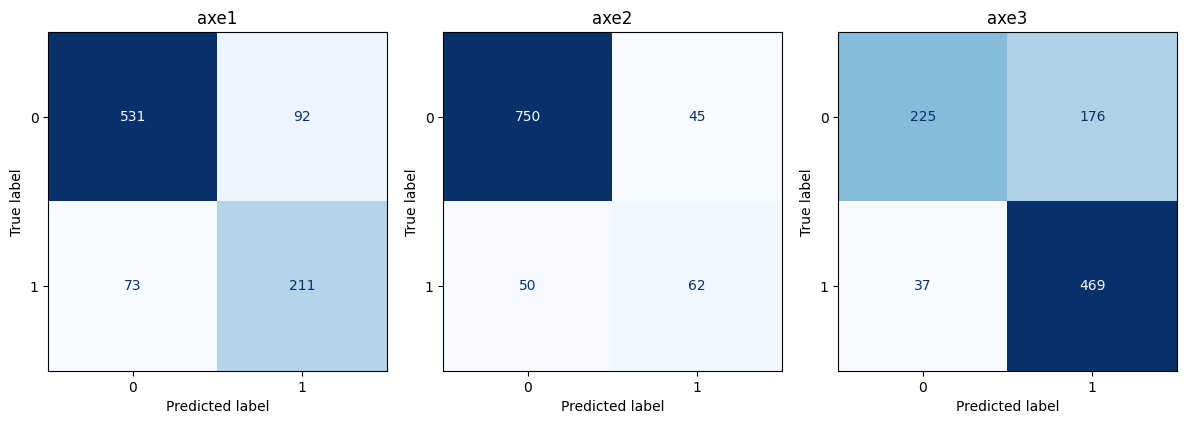

{'F1 micro': 0.7583035258048033,
 'F1 macro': 0.70002109447381,
 'F1 weighted': 0.7538218489061986,
 'Precision micro': 0.7033175355450237,
 'Recall micro': 0.8226164079822617}

In [ ]:
# ## 3CLASS MLP
importlib.reload(axe_classification)
from utils.axe_classification import predict_by_mlp, evaluate_model

out = predict_by_mlp(
    X_val,
    model_mlp,
    threshold=best_t_overall
)

evaluate_model(
    y_true=y_val[:, :3],
    y_pred=out["preds"],
    class_names=["axe1", "axe2", "axe3"]
)

## compa avec mlp de 4classes

Epoch 1/40 | Train Loss: 0.0567 | Val Loss: 0.0462 | F1_macro: 0.3399
F1 class 0: 0.5948
F1 class 1: 0.0000
F1 class 2: 0.7650
F1 class 3: 0.0000
Epoch 2/40 | Train Loss: 0.0459 | Val Loss: 0.0432 | F1_macro: 0.3616
F1 class 0: 0.6667
F1 class 1: 0.0000
F1 class 2: 0.7799
F1 class 3: 0.0000
Epoch 3/40 | Train Loss: 0.0420 | Val Loss: 0.0422 | F1_macro: 0.4012
F1 class 0: 0.6226
F1 class 1: 0.1890
F1 class 2: 0.7934
F1 class 3: 0.0000
Epoch 4/40 | Train Loss: 0.0385 | Val Loss: 0.0421 | F1_macro: 0.4636
F1 class 0: 0.6342
F1 class 1: 0.4250
F1 class 2: 0.7953
F1 class 3: 0.0000
Epoch 5/40 | Train Loss: 0.0389 | Val Loss: 0.0417 | F1_macro: 0.4703
F1 class 0: 0.6040
F1 class 1: 0.4828
F1 class 2: 0.7945
F1 class 3: 0.0000
Epoch 6/40 | Train Loss: 0.0370 | Val Loss: 0.0409 | F1_macro: 0.4697
F1 class 0: 0.6905
F1 class 1: 0.4129
F1 class 2: 0.7753
F1 class 3: 0.0000
Epoch 7/40 | Train Loss: 0.0364 | Val Loss: 0.0418 | F1_macro: 0.4743
F1 class 0: 0.6120
F1 class 1: 0.4912
F1 class 2: 0.79

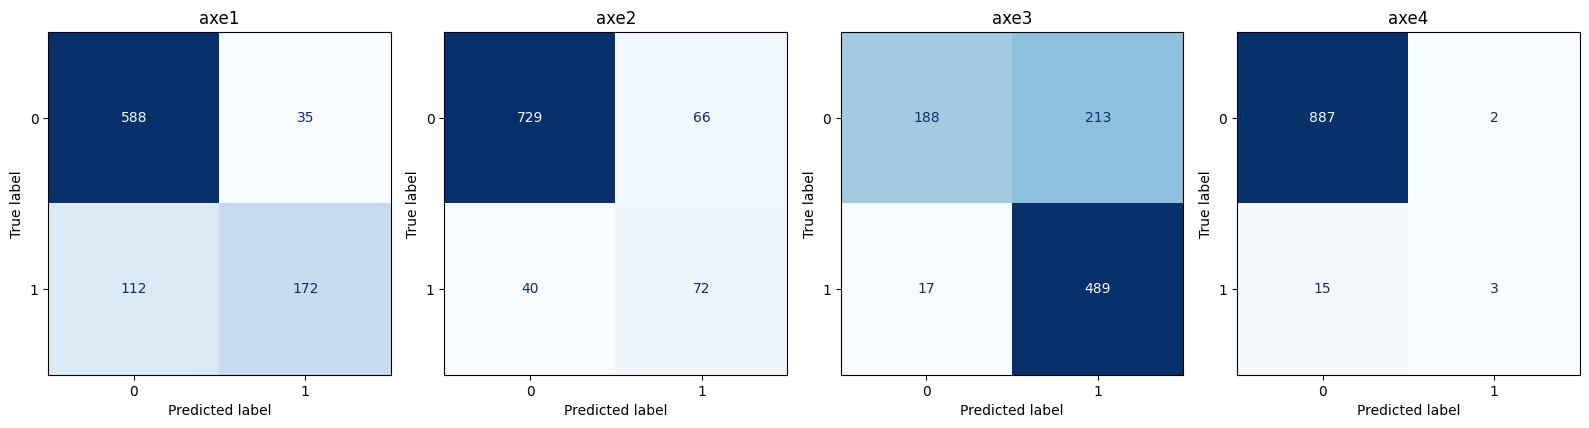

{'F1 micro': 0.7464503042596349,
 'F1 macro': 0.5867708030468385,
 'F1 weighted': 0.7367827347748398,
 'Precision micro': 0.6996197718631179,
 'Recall micro': 0.8}

In [7]:
importlib.reload(axe_classification)
from utils.axe_classification import train_multilabel_mlp_class

model_mlp_4class, best_t_overall_4class=train_multilabel_mlp_class (X_train,X_val,y_train, y_val, 
                n_classes=4,
                batch_size=32,dropout=0.5, n_epochs=40, patience=5, 
                model_path="../model/2024/mlp_4class.pt")

# ## 4CLASS MLP
importlib.reload(axe_classification)
from utils.axe_classification import predict_by_mlp, evaluate_model

out = predict_by_mlp(
    X_val,
    model_mlp_4class,
    threshold=best_t_overall_4class
)
evaluate_model(
    y_true=y_val,
    y_pred=out["preds"],
    class_names=["axe1", "axe2", "axe3",'axe4']
)

In [26]:
#----------------------------parameters-------------------------------
batch_size=32
dropout=0.5
n_epochs =40
patience=5
to_oversampling=True
mlp_model_path="../model/2024/mlp1.pt"

#------------------------- train mlp model---------------------------------
mlp_model, best_t_overall=mlp_multilabels(X_train, X_val, y_train, y_val, 
                                      batch_size=batch_size,dropout=dropout, n_epochs =n_epochs, 
                                      patience=10,to_oversampling=to_oversampling, 
                                      model_path=mlp_model_path)
print(f"[INFO]le meilleure seuil pour chaque classe :\n{best_t_overall}\n")

[INFO] y_train before oversampling:[302. 115. 478.  23.]
After oversampling: [304. 345. 496. 115.]
X shape: torch.Size([226, 1027]) y shape: torch.Size([226, 4])
X shape: torch.Size([1225, 1027]) y shape: torch.Size([1225, 4])
Epoch 1/40 | Train Loss: 0.0735 | Val Loss: 0.0661 | F1_macro: 0.6054

Epoch 2/40 | Train Loss: 0.0538 | Val Loss: 0.0610 | F1_macro: 0.6963

Epoch 3/40 | Train Loss: 0.0410 | Val Loss: 0.0522 | F1_macro: 0.7273

Epoch 4/40 | Train Loss: 0.0342 | Val Loss: 0.0534 | F1_macro: 0.7204

Epoch 5/40 | Train Loss: 0.0300 | Val Loss: 0.0510 | F1_macro: 0.7283

Epoch 6/40 | Train Loss: 0.0257 | Val Loss: 0.0516 | F1_macro: 0.7383

Epoch 7/40 | Train Loss: 0.0265 | Val Loss: 0.0456 | F1_macro: 0.7523

Epoch 8/40 | Train Loss: 0.0235 | Val Loss: 0.0524 | F1_macro: 0.7428

Epoch 9/40 | Train Loss: 0.0246 | Val Loss: 0.0466 | F1_macro: 0.7508

Epoch 10/40 | Train Loss: 0.0235 | Val Loss: 0.0490 | F1_macro: 0.7336

Epoch 11/40 | Train Loss: 0.0195 | Val Loss: 0.0550 | F1_macro

In [ ]:
# ## évaluation du mlp de 4classes
# importlib.reload(axe_classification)
# from utils.axe_classification import evaluate_model, predict_by_mlp

# preds_mlp, probs_mlp = predict_by_mlp(X_val, mlp_model, threshold=best_t_overall)
# evaluate_model(preds_mlp, y_val)

NameError: name 'importlib' is not defined

## lr

### only abstract!

In [20]:
df_long_totrain=df_long[df_long['source']=="abstract"]
print(len(df_long_totrain))

X = np.concatenate([df_long_totrain["text_emb"].tolist(), df_long_totrain["source_vec"].tolist()], axis=1)
y = df_long_totrain[['axe1','axe2','axe3','axe4']].values.astype(np.float32)
print(X.shape, y.shape)


#-------------------------------- split data---------------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from lightgbm import LGBMClassifier

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.metrics import classification_report, precision_recall_curve, f1_score
import joblib

#----------------- take labels 'axe4'-----------------
y_train_axe4 = y_train[:, 3]  
y_val_axe4 = y_val[:, 3]



# ----------------resampling: under+over--------------
rus = RandomUnderSampler(sampling_strategy=0.5, random_state=42)   # 保留部分多数类，一半？
X_rus, y_rus = rus.fit_resample(X_train, y_train_axe4)

sm = SMOTE(sampling_strategy=1, random_state=42)  # 0.5-1 根据需要
X_bal, y_bal = sm.fit_resample(X_rus, y_rus) # bal=balanced 

print(f"After resample y_train_axe4:\n", pd.Series(y_train_axe4).value_counts())
print(f"After resample y_val:\n", pd.Series(y_bal).value_counts())


# ---------------- 2) Standardization for LR ----------
scaler = StandardScaler()
X_bal_s = scaler.fit_transform(X_bal)
X_val_s = scaler.transform(X_val)
# X_val_s = scaler.transform(X_val_reduced)


# ---------------- 3) Logistic Regression --------------
lr = LogisticRegression(max_iter=2000)
lr.fit(X_bal_s, y_bal)

# calibration :  less extreme probs
#小类的预测概率会更合理，不会全部接近 0。阈值选择不再极端，更稳定。
cal_lr = CalibratedClassifierCV(lr, method='isotonic', cv='prefit')  # or 'sigmoid'
cal_lr.fit(X_val_s, y_val_axe4)  # 小数据集上可用验证集做calibration

#--------------------4) prediction--------------------
lr_model=cal_lr
probs_lr = lr_model.predict_proba(X_val_s)[:,1]
prob_true, prob_pred = calibration_curve(y_val_axe4, probs_lr, n_bins=10)

# --------------- 6) Threshold search (PR based) ----------
def best_thresh_by_pr(y_true, probs):
    prec, rec, th = precision_recall_curve(y_true, probs)
    f1 = 2 * prec * rec / (prec + rec + 1e-12)
    # th length = len(prec)-1 ; align accordingly
    best_idx = np.nanargmax(f1)
    # handle if best_idx equals last of prec (no threshold)
    if best_idx >= len(th):
        return 0.5
    return th[best_idx]

t_lr = best_thresh_by_pr(y_val_axe4, probs_lr)
print("best t lr:", t_lr)

pred_lr = (probs_lr >= t_lr).astype(int)

print("[LR] axe4")
print(classification_report(y_val_axe4, pred_lr, digits=4))

from sklearn.metrics import f1_score


## save
f1_axe4 = f1_score(
    y_val_axe4,
    pred_lr,
    pos_label=1
)
lr_model_path=f"../model/2024/model_lr_abstract_{f1_axe4:.2f}1.pt"
joblib.dump(cal_lr, lr_model_path)
print(f"[SAVE] LR model saved to {lr_model_path}")

1129
(1129, 1027) (1129, 4)
After resample y_train_axe4:
 0.0    880
1.0     23
Name: count, dtype: int64
After resample y_val:
 0.0    46
1.0    46
Name: count, dtype: int64
best t lr: 0.5
[LR] axe4
              precision    recall  f1-score   support

         0.0     1.0000    0.9910    0.9955       222
         1.0     0.6667    1.0000    0.8000         4

    accuracy                         0.9912       226
   macro avg     0.8333    0.9955    0.8977       226
weighted avg     0.9941    0.9912    0.9920       226

[SAVE] LR model saved to ../model/2024/model_lr_abstract_0.801.pt


d:\miniconda3\envs\irg_env\lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


                                Overall metrics                                 
F1 micro            : 0.8235
F1 macro            : 0.7973
F1 weighted         : 0.8200
Precision micro     : 0.7632
Recall micro        : 0.8943

                                Per-class report                                
              precision    recall  f1-score   support

     class_0       0.77      0.87      0.82        67
     class_1       0.84      0.64      0.72        33
     class_2       0.75      0.98      0.85       123
     class_3       0.67      1.00      0.80         4

   micro avg       0.76      0.89      0.82       227
   macro avg       0.76      0.87      0.80       227
weighted avg       0.77      0.89      0.82       227
 samples avg       0.81      0.89      0.84       227



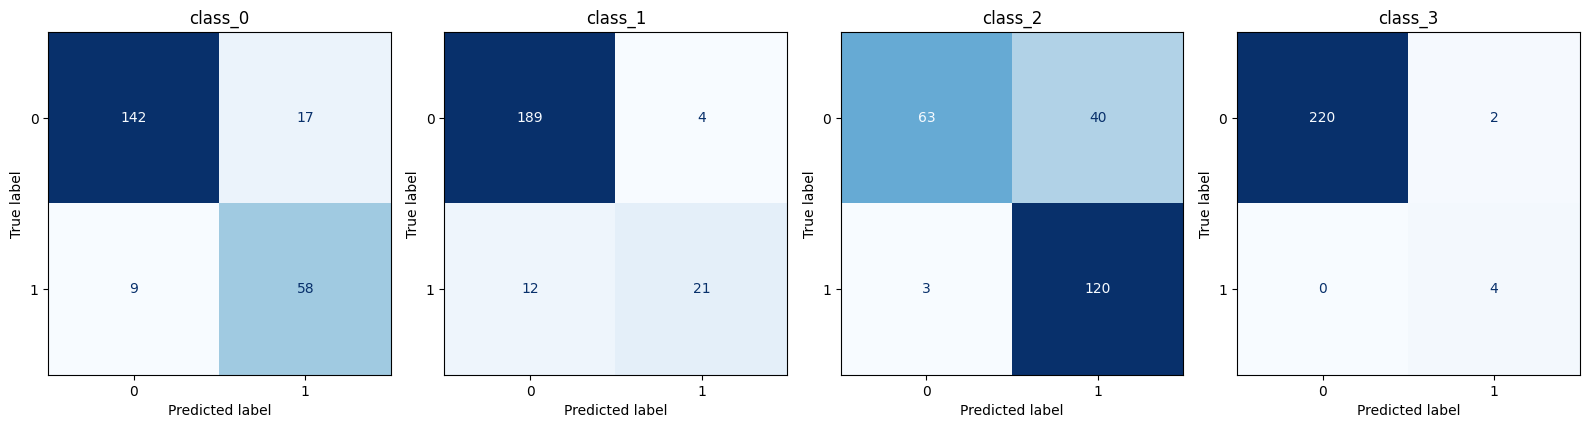

{'F1 micro': 0.8235294117647058,
 'F1 macro': 0.7972739691469151,
 'F1 weighted': 0.8199995601495126,
 'Precision micro': 0.7631578947368421,
 'Recall micro': 0.8942731277533039}

In [21]:
# LR+MLP
importlib.reload(axe_classification)
from utils.axe_classification import predict_by_mlp, evaluate_model

out = predict_by_mlp(
    X_val,
    model_mlp,
    threshold=best_t_overall
)

probs_val_mlp=out['probs']

# final_axe :MLP for axe12, LR for axe4
pred_final = np.zeros_like(y_val)
pred_final[:, :3] = (probs_val_mlp[:, :3] >= best_t_overall[:3]).astype(int)
pred_final[:, 3] = pred_lr  # LR 预测 axe4
evaluate_model(y_true=y_val, y_pred=pred_final)

## combo

all: 248 ; has axe: 96 

has axes :
 axe
3          57
1          31
1; 3        4
1; 2        2
2           1
1; 2; 3     1
Name: count, dtype: int64
df_hasaxe_long: 234
[INFO] Input X shape: (234, 1027)
[INFO] Valid ground-truth labels found → go to model evaluation!

------------------------------ Evaluation ------------------------------
                                Overall metrics                                 
F1 micro            : 0.7140
F1 macro            : 0.4589
F1 weighted         : 0.7000
Precision micro     : 0.6940
Recall micro        : 0.7352

                                Per-class report                                
              precision    recall  f1-score   support

     class_0       0.62      0.46      0.53        87
     class_1       0.45      0.56      0.50         9
     class_2       0.73      0.90      0.81       157
     class_3       0.00      0.00      0.00         0

   micro avg       0.69      0.74      0.71       253
   macro avg       0.4

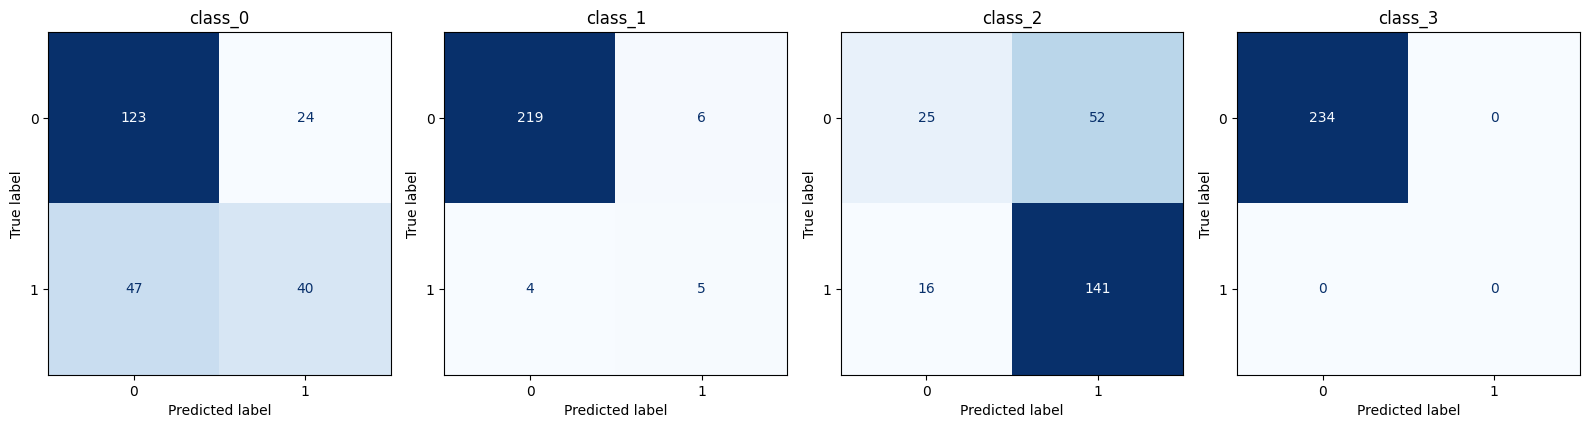

,text_emb,halId_s,source,axe1,axe2,axe3,axe4,source_id,source_vec,pred_axe1,pred_axe2,pred_axe3,pred_axe4
0,"[-0.07416533, -0.02507004, -0.056212127, -0.00...",hal-05354091,title,0.0,0.0,1.0,0.0,0,"[1.0, 0.0, 0.0]",0,0,1,0
1,"[-0.038245093, -0.003676773, -0.055256307, -0....",hal-05354091,keyword,0.0,0.0,1.0,0.0,1,"[0.0, 1.0, 0.0]",0,0,1,0
2,"[-0.0627323, -0.012661392, -0.04260565, -0.003...",hal-05354091,abstract,0.0,0.0,1.0,0.0,2,"[0.0, 0.0, 1.0]",0,0,1,0
3,"[-0.022757635, -0.0064444183, -0.042470817, 0....",hal-05321456,title,0.0,0.0,1.0,0.0,0,"[1.0, 0.0, 0.0]",0,0,1,0
4,"[-0.03761582, -0.006678919, -0.009912152, 0.01...",hal-05302743,title,0.0,0.0,1.0,0.0,0,"[1.0, 0.0, 0.0]",0,0,1,0


In [ ]:
importlib.reload(axe_classification)
from utils.axe_classification import load_predict_by_mlp_lr

df_after_2024=pd.read_parquet("../external_data\embeddings_all\df_after2024_3emb.parquet")
df_after_2024_hasaxe=df_after_2024[df_after_2024['axe'].notna()]
print('all:', len(df_after_2024),'; has axe:',len(df_after_2024_hasaxe),"\n")
print(f'has axes :\n {df_after_2024_hasaxe.axe.value_counts(dropna=False)}')#NO axe4!!

df_after_2024_hasaxe_long=to_df_long(df_after_2024_hasaxe)
print('df_hasaxe_long:',len(df_after_2024_hasaxe_long))

df_long_predicted=load_predict_by_mlp_lr(
    df_after_2024_hasaxe_long,
    path_mlp="../model/2024/mlp_3class.pt",
    path_lr="../model/2024/model_lr_abstract_0.80.pt",
    t_lr=0.5,
    class_names_mlp=("axe1", "axe2", "axe3"),
    class_name_lr="axe4",
)

display(df_long_predicted.head())

## prédiction sur les article sans axes!

In [23]:
importlib.reload(axe_classification)
from utils.axe_classification import load_predict_by_mlp_lr

df_noaxe=pd.read_parquet('../external_data\embeddings_all\df_noaxe_3emb.parquet')
df_noaxe_long=to_df_long(df_noaxe)
# display(df_noaxe_long.head())



df_noaxe_predicted=load_predict_by_mlp_lr(
    df_noaxe_long,
    path_mlp="../model/2024/mlp_3class.pt",
    path_lr="../model/2024/model_lr_abstract_0.80.pt",
    t_lr=0.5,
    class_names_mlp=("axe1", "axe2", "axe3"),
    class_name_lr="axe4",
)

display(df_noaxe_predicted.head())

[INFO] Input X shape: (1362, 1027)
[INFO] No valid ground-truth labels found → skip evaluation, prediction only.


,text_emb,halId_s,source,axe1,axe2,axe3,axe4,source_id,source_vec,pred_axe1,pred_axe2,pred_axe3,pred_axe4
0,"[-0.04155007, -0.023307052, 0.0016010036, -0.0...",hal-05388365,title,0.0,0.0,0.0,0.0,0,"[1.0, 0.0, 0.0]",1,0,1,0
1,"[-0.018936373, -0.021172136, -0.0118464315, -0...",hal-05388365,abstract,0.0,0.0,0.0,0.0,2,"[0.0, 0.0, 1.0]",1,0,1,0
2,"[-0.016558325, -0.03287933, -0.008555193, -0.0...",hal-05388364,title,0.0,0.0,0.0,0.0,0,"[1.0, 0.0, 0.0]",1,0,1,0
3,"[0.012655695, -0.021638852, -0.016811978, -0.0...",hal-05388364,keyword,0.0,0.0,0.0,0.0,1,"[0.0, 1.0, 0.0]",0,0,1,0
4,"[-0.026050236, -0.036349155, -0.027868139, -0....",hal-05388364,abstract,0.0,0.0,0.0,0.0,2,"[0.0, 0.0, 1.0]",0,0,1,0


In [24]:
from utils.axe_classification import gather_predicted_axes, merge_axes
# df_all=pd.read_csv("../sandbox\data/20251201-ProductionScientifiqueIRG-__-202512_2734art.csv")
df_all=pd.read_parquet("../external_data\embeddings_all\df_all_3emb.parquet")

df_long_predicted=df_noaxe_predicted.copy()

# gather pred_axes by halId
df_all=gather_predicted_axes(df_long_predicted=df_long_predicted,
                      df_all=df_all, 
                      groupby_col="halId_s")

## merge axe & predicted_axe to final_axe
df_all['final_axe']=df_all.apply(merge_axes, axis=1)
# display(df_all[['halId_s','axe','predicted_axe','final_axe']].head())
# print(df_all.final_axe.value_counts(dropna=False))
display(df_all[["axe",'predicted_axe','final_axe']].head())
df_all.to_parquet("../external_data/embeddings_all/df_all_3emb_predicted.parquet")

[INFO] Au moins une prédiction pour chaque ligne non-axée!


,axe,predicted_axe,final_axe
14,3,NaN,3
20,3,NaN,3
33,3,NaN,3
40,3,NaN,3
42,3,NaN,3


In [ ]:
# df_all.to_csv("../sandbox\data_axe/20251201-ProductionScientifiqueIRG-__-202512_2734art_predicted.csv",index=False)